In [2]:
%%capture
import os
import importlib.util

def in_colab():
    return "COLAB_" in "".join(os.environ.keys())

def package_installed(pkg_name):
    return importlib.util.find_spec(pkg_name) is not None

# Setup numpy and pillow version strings if available
def get_numpy_pillow_versions():
    try:
        import numpy
        import PIL
        return f"numpy=={numpy.__version__}", f"pillow=={PIL.__version__}"
    except Exception:
        return "numpy", "pillow"

if not package_installed("torch") or in_colab():
    _numpy, _pil = get_numpy_pillow_versions()
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif not package_installed("unsloth"):
    !uv pip install -qqq unsloth

!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.3.0
# causal_conv1d is supported only on torch==2.8.0. If you have newer torch versions, please wait 10 minutes!
!uv pip install --no-build-isolation flash-linear-attention causal_conv1d==1.6.0
!uv pip install roboflow supervision

In [3]:
if in_colab():
    from google.colab import drive
    drive.mount('/content/drive/', force_remount=True)
    %cd drive/MyDrive/colab_local/vlm_finetune
    %ls

Mounted at /content/drive/
/content/drive/MyDrive/colab_local/vlm_finetune
hf_models/  pallet-load-manifest-json-2/  unsloth_compiled_cache/


In [ ]:
import os

os.environ["HF_TOKEN"] = ""
os.environ["ROBOFLOW_API_KEY"] = ""
os.environ["HF_HOME"] = f"{os.getcwd()}/hf_models"

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3.5-0.8B",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [6]:
!nvidia-smi

Fri Mar  6 17:23:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   35C    P0             89W /  600W |    1769MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [7]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [21]:
from datasets import load_dataset
dataset_ocr = load_dataset("unsloth/LaTeX_OCR", split = "train")

In [15]:
from roboflow import download_dataset

dataset = download_dataset("https://app.roboflow.com/roboflow-jvuqo/pallet-load-manifest-json/2", "jsonl")

loading Roboflow workspace...
loading Roboflow project...


In [10]:
!ls

hf_models  pallet-load-manifest-json-2	unsloth_compiled_cache


In [11]:
!head -n 3 {dataset.location}/train/annotations.jsonl

head: cannot open '{dataset.location}/train/annotations.jsonl' for reading: No such file or directory


In [41]:
import os
import json
from PIL import Image
from torch.utils.data import Dataset

SYSTEM_MESSAGE = """You are a Vision Language Model specialized in extracting structured data from visual representations of palette manifests.
Your task is to analyze the provided image of a palette manifest and extract the relevant information into a well-structured JSON format.
The palette manifest includes details such as item names, quantities, dimensions, weights, and other attributes.
Focus on identifying key data fields and ensuring the output adheres to the requested JSON structure.
Provide only the JSON output based on the extracted information. Avoid additional explanations or comments."""
instruction = f"{SYSTEM_MESSAGE} Extract data in JSON format"

class JSONLDataset(Dataset):
    """Dataset qui renvoie le format messages pour Qwen3-VL."""

    def __init__(self, jsonl_file_path: str, image_directory_path: str):
        self.image_directory_path = image_directory_path
        self.entries = self._load_entries(jsonl_file_path)

    def _load_entries(self, path):
        with open(path) as f:
            return [json.loads(line) for line in f]

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx: int):
        entry = self.entries[idx]
        image_path = os.path.join(self.image_directory_path, entry["image"])
        image = Image.open(image_path)

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": instruction},
                ],
            },
            {"role": "assistant", "content": entry["suffix"]},
        ]
        return {"messages": messages}

In [16]:
train_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset.location}/train/annotations.jsonl",
    image_directory_path=f"{dataset.location}/train",
)
valid_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset.location}/valid/annotations.jsonl",
    image_directory_path=f"{dataset.location}/valid",
)
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset.location}/test/annotations.jsonl",
    image_directory_path=f"{dataset.location}/test",
)

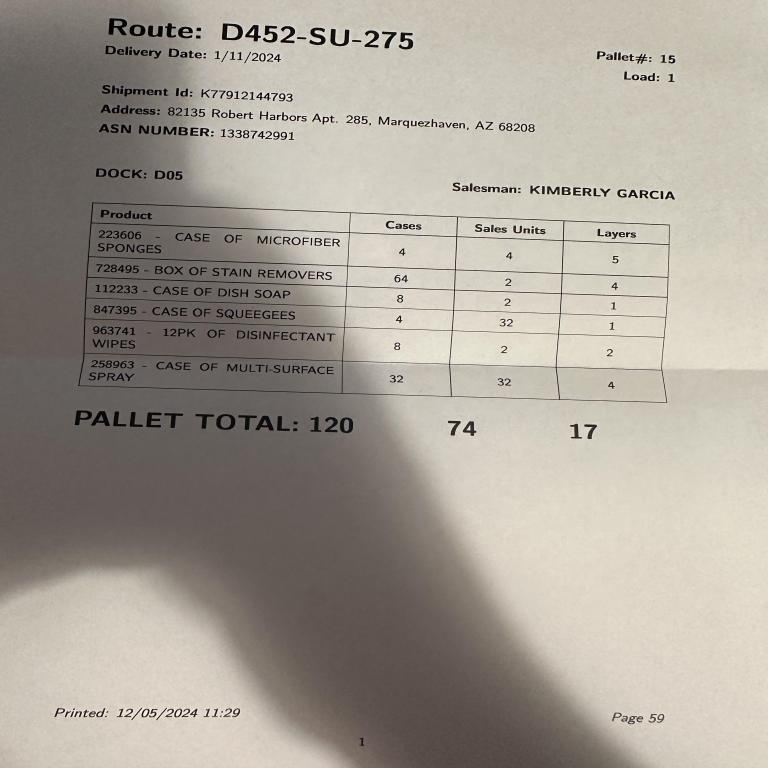

In [17]:
train_dataset[0]["messages"][0]["content"][0]["image"]

In [18]:
train_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=768x768>},
    {'type': 'text',
     'text': 'You are a Vision Language Model specialized in extracting structured data from visual representations of palette manifests.\nYour task is to analyze the provided image of a palette manifest and extract the relevant information into a well-structured JSON format.\nThe palette manifest includes details such as item names, quantities, dimensions, weights, and other attributes.\nFocus on identifying key data fields and ensuring the output adheres to the requested JSON structure.\nProvide only the JSON output based on the extracted information. Avoid additional explanations or comments. Extract data in JSON format'}]},
  {'role': 'assistant',
   'content': '{"route": "D452-SU-275","pallet_number": "15","delivery_date": "1/11/2024","load": "1","dock": "D05","shipment_id": "K77912144793","destination": "82135 Robert 

In [26]:
FastVisionModel.for_inference(model) # Enable for inference!
from transformers import TextStreamer  # noqa: E402

image = train_dataset[0]["messages"][0]["content"][0]["image"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

```json
[
  {
    "product": "223606 - CASE OF MICROFIBER SPONGES",
    "cases": 4,
    "sales_units": 4,
    "layers": 5
  },
  {
    "product": "728495 - BOX OF STAIN REMOVERS",
    "cases": 64,
    "sales_units": 2,
    "layers": 4
  },
  {
    "product": "112233 - CASE OF DISH SOAP",
    "cases": 8,
    "sales_units": 2,
    "layers": 1
  },
  {
    "product": "847395 - CASE OF SQUEEGES",
    "cases": 4,
    "sales_units": 32,
    "layers": 1
  },
  {
    "product": "963741 - 12PK OF DISINFECTANT WIPES",
    "cases": 8,
    "sales_units": 2,
    "layers": 2
  },
  {
    "product": "258963 - CASE OF MULTI-SURFACE SPRAY",
    "cases": 32,
    "sales_units": 32,
    "layers": 4
  }
]
```<|im_end|>
<|endoftext|>


In [30]:
!nvidia-smi

Fri Mar  6 17:35:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   36C    P0             89W /  600W |    2705MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [28]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = train_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX PRO 6000 Blackwell Server Edition. Max memory = 94.971 GB.
1.592 GB of memory reserved.


In [31]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 150 | Num Epochs = 2 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,181,952 of 866,167,872 (1.52% trained)


Step,Training Loss
1,0.964659
2,0.995008
3,0.956116
4,0.846168
5,0.762995
6,0.582793
7,0.448727
8,0.360329
9,0.268310
10,0.164512


In [35]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

133.3083 seconds used for training.
2.22 minutes used for training.
Peak reserved memory = 3.016 GB.
Peak reserved memory for training = 1.424 GB.
Peak reserved memory % of max memory = 3.176 %.
Peak reserved memory for training % of max memory = 1.499 %.


In [36]:
FastVisionModel.for_inference(model) # Enable for inference!
from transformers import TextStreamer  # noqa: E402

image = train_dataset[0]["messages"][0]["content"][0]["image"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]

input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

{"route": "D452-SU-275","pallet_number": "15","delivery_date": "1/11/2024","load": "1","dock": "D05","shipment_id": "K77912144793","destination": "82135 Robert Harbors Apt. 285, Marquezhaven, AZ 68208","asn_number": "1338742991","salesman": "KIMBERLY GARCIA","products": [{"description": "223606 - CASE OF MICROFIBER SPONGES","cases": "4","sales_units": "4","layers": "5"},{"description": "728495 - BOX OF STAIN REMOVERS","cases": "64","sales_units": "2","layers": "4"},{"description": "112233 - CASE OF DISH SOAP","cases": "8","sales_units": "2","layers": "1"},{"description": "847395 - CASE OF SQUEEGEES","cases": "4","sales_units": "32","layers": "1"},{"description": "963741 - 12PK OF DISINFECTANT WIPES","cases": "8","sales_units": "2","layers": "2"},{"description": "258963 - CASE OF MULTI-SURFACE SPRAY","cases": "32","sales_units": "32","layers": "4"}],"total_cases": "120","total_units": "74","total_layers": "17","printed_date": "12/05/2024 11:29","page_number": "59"}<|im_end|>


In [ ]:
model.save_pretrained("qwen_0.8B_lora_vlm_extract")  # Local saving
tokenizer.save_pretrained("qwen_0.8B_lora_vlm_extract")
model.push_to_hub("kapygenius/qwen_0.8B_lora_vlm_extract", token = os.environ["HF_TOKEN"]) # Online saving
tokenizer.push_to_hub("kapygenius/qwen_0.8B_lora_vlm_extract", token = os.environ["HF_TOKEN"]) # Online saving

README.md:   0%|          | 0.00/536 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 52.8MB / 52.8MB            

Saved model to https://huggingface.co/kapygenius/qwen_0.8B_lora_vlm_extract


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpj4gqy1tr/tokenizer.json: 100%|##########| 20.0MB / 20.0MB            

  ...mpj4gqy1tr/tokenizer.json: 100%|##########| 20.0MB / 20.0MB            

In [45]:
if True:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "kapygenius/qwen_0.8B_lora_vlm_extract", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
    FastVisionModel.for_inference(model) # Enable for inference!

image = test_dataset[0]["messages"][0]["content"][0]["image"]

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer  # noqa: E402
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 1024,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

==((====))==  Unsloth 2026.3.3: Fast Qwen3_5 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

{"route": "J414-YG-624","pallet_number": "17","delivery_date": "9/18/2024","load": "1","dock": "D08","shipment_id": "P18941494362","destination": "595 Navarro Radial Suite 559, Port Erika, HI 29655","asn_number": "4690787672","salesman": "CAROL FREDERICK","products": [{"description": "159753 - BOX OF PAPER CUPS","cases": "32","sales_units": "8","layers": "2"},{"description": "583947 - BOX OF CLOTH RAGS","cases": "8","sales_units": "2","layers": "5"},{"description": "357951 - 6PK OF HAND SANITIZER","cases": "2","sales_units": "32","layers": "4"},{"description": "847295 - CASE OF DISPOSABLE CAPS","cases": "16","sales_units": "4","layers": "3"}],"total_cases": "58","total_units": "46","total_layers": "14","printed_date": "12/05/2024 10:14","page_number": "60"}<|im_end|>
<|endoftext|>


In [46]:
test_dataset[0]["messages"][1]["content"]

'{"route": "J414-YG-624","pallet_number": "17","delivery_date": "9/18/2024","load": "1","dock": "D08","shipment_id": "P18941494362","destination": "595 Navarro Radial Suite 559, Port Erika, HI 29655","asn_number": "4690787672","salesman": "CAROL FREDERICK","products": [{"description": "159753 - BOX OF PAPER CUPS","cases": "32","sales_units": "8","layers": "2"},{"description": "583947 - BOX OF CLOTH RAGS","cases": "8","sales_units": "2","layers": "5"},{"description": "357951 - 6PK OF HAND SANITIZER","cases": "2","sales_units": "32","layers": "4"},{"description": "847295 - CASE OF DISPOSABLE CAPS","cases": "16","sales_units": "4","layers": "3"}],"total_cases": "58","total_units": "46","total_layers": "14","printed_date": "12/05/2024 10:14","page_number": "60"}'

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 8bit Q8_0
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer,)
# Remember to go to https://huggingface.co/settings/tokens for a token!
# And change hf to your username!
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, token = "YOUR_HF_TOKEN")

# Save to 16bit GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "f16")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "f16", token = "YOUR_HF_TOKEN")

# Save to q4_k_m GGUF
if False: model.save_pretrained_gguf("qwen_finetune", tokenizer, quantization_method = "q4_k_m")
if False: model.push_to_hub_gguf("HF_USERNAME/qwen_finetune", tokenizer, quantization_method = "q4_k_m", token = "YOUR_HF_TOKEN")

# Save to multiple GGUF options - much faster if you want multiple!
if False:
    model.push_to_hub_gguf(
        "HF_USERNAME/qwen_finetune", # Change hf to your username!
        tokenizer,
        quantization_method = ["q4_k_m", "q8_0", "q5_k_m",],
        token = "YOUR_HF_TOKEN",
    )

# thanks to https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(0_8B)_Vision.ipynb#scrollTo=At1T2hJnOdGM